Sample Dataset:
   Weather   Soil Temperature Humidity    Wind Fertilizer Crop Type  Season  \
0   Rainy  Moist         Hot     High    Weak        Yes      Corn    Rabi   
1   Sunny    Dry        Cool      Low    Weak        Yes      Rice    Rabi   
2   Rainy  Moist        Mild   Medium  Strong        Yes      Rice  Kharif   
3   Rainy  Moist        Cool     High  Strong        Yes      Rice  Kharif   
4   Sunny  Moist        Cool     High    Weak         No      Rice  Kharif   

  irrigate  
0       No  
1      Yes  
2       NO  
3       No  
4       NO  

Accuracy Comparison:
Decision Tree Accuracy: 0.8333333333333334
Random Forest Accuracy: 0.6666666666666666


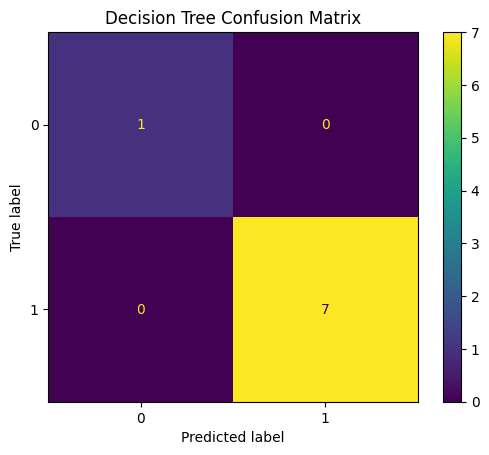

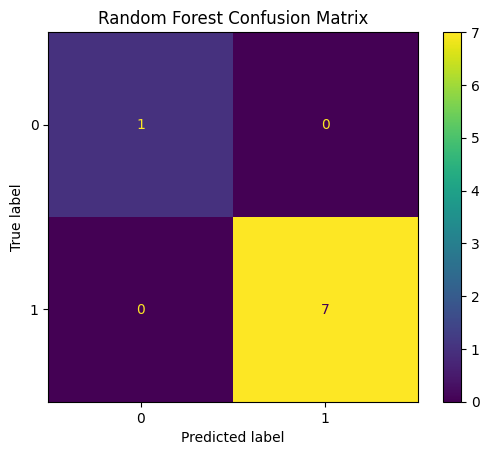


Cross Validation Accuracy:
Decision Tree: 0.7333333333333333
Random Forest: 0.7833333333333333

Feature Importance:
        Feature  Importance
1         Soil    0.310181
3     Humidity    0.173684
4         Wind    0.104632
6    Crop Type    0.096966
0      Weather    0.091512
7       Season    0.078102
5   Fertilizer    0.076329
2  Temperature    0.068593


In [ ]:
#1.Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

#2.Generate Larger Farming Dataset(8 features)

np.random.seed(42)
n_samples=60

data={
    'Weather':np.random.choice(['Sunny','Cloudy','Rainy'],n_samples),
    'Soil':np.random.choice(['Dry','Moist','Wet'],n_samples),
    'Temperature':np.random.choice(['Hot','Mild','Cool'],n_samples),
    'Humidity':np.random.choice(['High','Medium','Low'],n_samples),
    'Wind':np.random.choice(['Strong','Weak'],n_samples),
    'Fertilizer':np.random.choice(['Yes','No'],n_samples),
    'Crop Type':np.random.choice(['Wheat','Rice','Corn'],n_samples),
    'Season':np.random.choice(['Kharif','Rabi','Summer'],n_samples)
}

df=pd.DataFrame(data)

#3.Create Target Varibles(Rule-based for realism)
def irrigation_rule(row):
  if row['Soil']=='Dry' and row['Weather']!='Rainy':
     return 'Yes'
  elif row['Soil']=='Wet':
     return 'No'
  elif row['Humidity']=='High'and row['Weather']=='Rainy':
    return 'No'
  else:
    return np.random.choice(['Yes','NO'])
df['irrigate']=df.apply(irrigation_rule,axis=1)
print("Sample Dataset:\n",df.head())


#4.Encode categorical variables
le_dict={}
for column in df.columns:
  le=LabelEncoder()
  df[column] = le.fit_transform(df[column])
  le_dict[column]=le

#5.split features and target
x=df.drop('irrigate',axis=1)
y=df['irrigate']


#6.train-test split(STRATIFIED)
X_train,X_test,y_train,y_test=train_test_split(
x,y,test_size=0.3,random_state=42,stratify=y
)


#7.Decision tree model
dt_model=DecisionTreeClassifier(criterion='entropy',random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)

#8.Random forest model
rf_model=RandomForestClassifier(
    n_estimators=20,
    criterion='entropy',
    random_state=42
)

rf_model.fit(X_train,y_train)

y_pred_rf=rf_model.predict(X_test)

#9.Accuracy evaluation
dt_accuracy=accuracy_score(y_test,y_pred_dt)
rf_accuracy=accuracy_score(y_test,y_pred_rf)

print("\nAccuracy Comparison:")
print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

#10. confusion matrix (FIXED+MEANINGFUL)
cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])

cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])

#11.Cnfusion Matrix Visualization
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt,labels=[0,1])
plt.title("Decision Tree Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt,labels=[0,1])
plt.title("Random Forest Confusion Matrix")
plt.show()

#12.Cross Validation
dt_cv=cross_val_score(dt_model,x,y,cv=5)
rf_cv=cross_val_score(rf_model,x,y,cv=5)

print("\nCross Validation Accuracy:")
print("Decision Tree:",dt_cv.mean())
print("Random Forest:",rf_cv.mean())

#13.Features importance(Random Forest)
importance=pd.DataFrame({
    'Feature':x.columns,
    'Importance':rf_model.feature_importances_
}).sort_values(by='Importance',ascending=False)

print("\nFeature Importance:\n",importance)
